# Housing Price Prediction

## Importing data and Libraries 

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

In [33]:
train = pd.read_csv("../Data/house/train.csv")
test = pd.read_csv("../Data/house/test.csv")

## Basic EDA

In [34]:
train.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


#### Checking for null values

Null values will remain the same in both training and testing set as these are not missing values these are predetermined text values

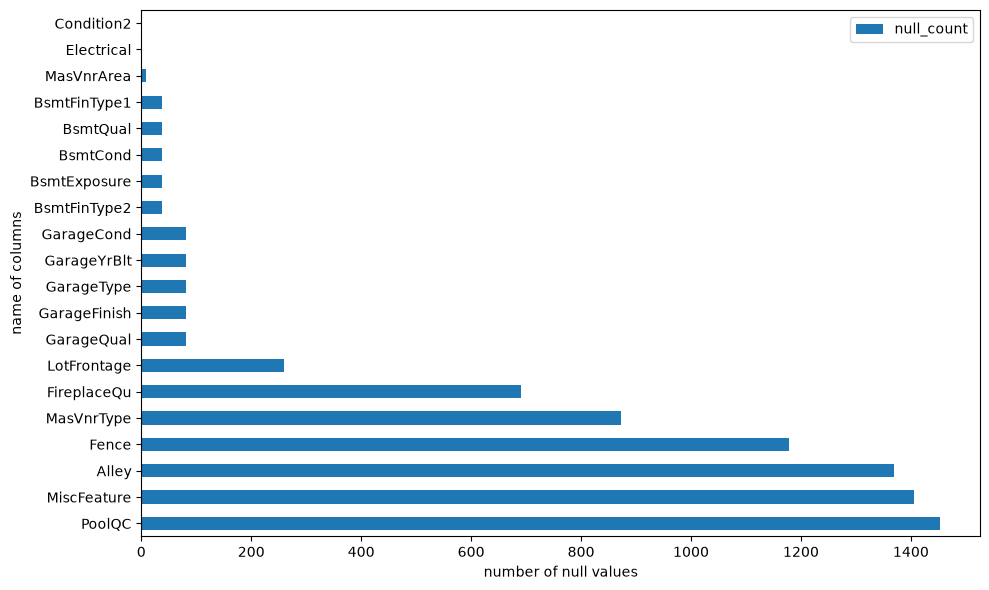

In [35]:
null_data = train.isnull().sum()
null_df = null_data.reset_index()
null_df.columns = ['Column_name', 'null_count']
null_df = null_df.sort_values('null_count', ascending= False)
null_df.head(20).plot(y = "null_count", x = "Column_name", kind= 'barh', figsize=(10, 6))
plt.xlabel('number of null values')
plt.ylabel('name of columns')
plt.tight_layout()
plt.show()

#### Treating Null Values

In [36]:
def null_value(df):
    # Dealing with null values leaving year built behind 
    df = df.copy()
    garage_col = ['GarageYrBlt'] 
    for col in df:
        if col in garage_col:
            df['has_garage'] = df[col].notnull().astype(int) 
            # I'm making a new column or feature here because it's easy to do here than some code blocks later
            df[col] = df[col].fillna(df['YearBuilt'])
        if df[col].dtype == 'str':
            df[col] = df[col].fillna('None')
        elif df[col].dtype in ('int', 'float'):
            df[col] = df[col].fillna(0)
    return df    
    
    # Always use 'in' rather that '==' as this will not have precedence over 'in' if you want to try replace 'in' from exclude_col line with '=='
    # Alternate way to deal with null values
    # ---- Code ----
    # cat_cols = df.select_dtypes(include = 'str').columns
    # df[cat_cols] = df[cat_cols].fillna('None')
    # int_cols = df.select_dtypes(include = 'int', 'float').columns
    # df[int_cols] = df[int_cols].fillna('0')
    # return df
    # ---- Code ----
    # this will not leave behind the column we want as we are leaving year built behind as we have to deal with it separately

train = null_value(train)
test = null_value(test)

#### Encoding Values


In [37]:
# First treating the Quality Parameters
group = ['ExterQual', 'ExterCond', 'HeatingQC', 'KitchenQual', 'BsmtQual', 'BsmtCond', 'FireplaceQu', 'GarageQual', 'GarageCond']
group_t = ['PoolQC']
cat_catg = ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
cat_catg_t = ['None', 'Fa', 'TA', 'Gd', 'Ex']

for col in group:
    enc = OrdinalEncoder(categories= [cat_catg])
    train[col] = enc.fit_transform(train[[col]])
    test[col] = enc.transform(test[[col]])
   
for col in group_t:
    enc = OrdinalEncoder(categories= [cat_catg_t])
    train[col] = enc.fit_transform(train[[col]])
    test[col] = enc.transform(test[[col]])